In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 130

In [3]:
data = 'https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv'
!wget $data

--2026-05-28 13:46:39--  https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182489 (178K) [text/plain]
Saving to: ‘CreditScoring.csv.1’

CreditScoring.csv.1 100%[===================>] 178.21K  --.-KB/s    in 0.04s   

2026-05-28 13:46:40 (4.32 MB/s) - ‘CreditScoring.csv.1’ saved [182489/182489]



In [4]:
df = pd.read_csv('CreditScoring.csv')

In [50]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9.0,rent,60.0,30.0,married,no_rec,freelance,73.0,129.0,0.0,0.0,800.0,846.0
1,0,17.0,rent,60.0,58.0,widow,no_rec,fixed,48.0,131.0,0.0,0.0,1000.0,1658.0
2,1,10.0,owner,36.0,46.0,married,yes_rec,freelance,90.0,200.0,3000.0,0.0,2000.0,2985.0
3,0,0.0,rent,60.0,24.0,single,no_rec,fixed,63.0,182.0,2500.0,0.0,900.0,1325.0
4,0,0.0,rent,36.0,26.0,single,no_rec,fixed,46.0,107.0,0.0,0.0,310.0,910.0


In [53]:
df.isnull().sum()

status       0
seniority    0
home         0
time         0
age          0
marital      0
records      0
job          0
expenses     0
income       0
assets       0
debt         0
amount       0
price        0
dtype: int64

In [54]:
df.dtypes

status         int64
seniority    float64
home             str
time         float64
age          float64
marital          str
records          str
job              str
expenses     float64
income       float64
assets       float64
debt         float64
amount       float64
price        float64
dtype: object

In [55]:
df.describe()

,status,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.00000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000
mean,0.281481,7.977553,46.436364,37.06330,55.539731,130.487542,5378.077890,341.562963,1038.123906,1460.689338
std,0.449772,8.151542,14.650238,10.96531,19.426739,86.042072,11514.557029,1243.532086,470.816388,611.120065
min,0.000000,0.000000,6.000000,18.00000,35.000000,0.000000,0.000000,0.000000,100.000000,105.000000
25%,0.000000,2.000000,36.000000,28.00000,35.000000,80.000000,0.000000,0.000000,700.000000,1117.500000
50%,0.000000,5.000000,48.000000,36.00000,50.500000,120.000000,3000.000000,0.000000,1000.000000,1400.000000
75%,1.000000,12.000000,60.000000,45.00000,72.000000,164.000000,6000.000000,0.000000,1300.000000,1691.000000
max,1.000000,47.000000,60.000000,66.00000,173.000000,959.000000,300000.000000,30000.000000,4500.000000,8800.000000


# Exploratory data analysis
- Key questions: which applicants defaulted, and why 

In [69]:

num_col = list(df.dtypes[df.dtypes == 'float'].index)
cat_col = list(df.dtypes[df.dtypes == 'str'].index)


['seniority',
 'time',
 'age',
 'expenses',
 'income',
 'assets',
 'debt',
 'amount',
 'price']

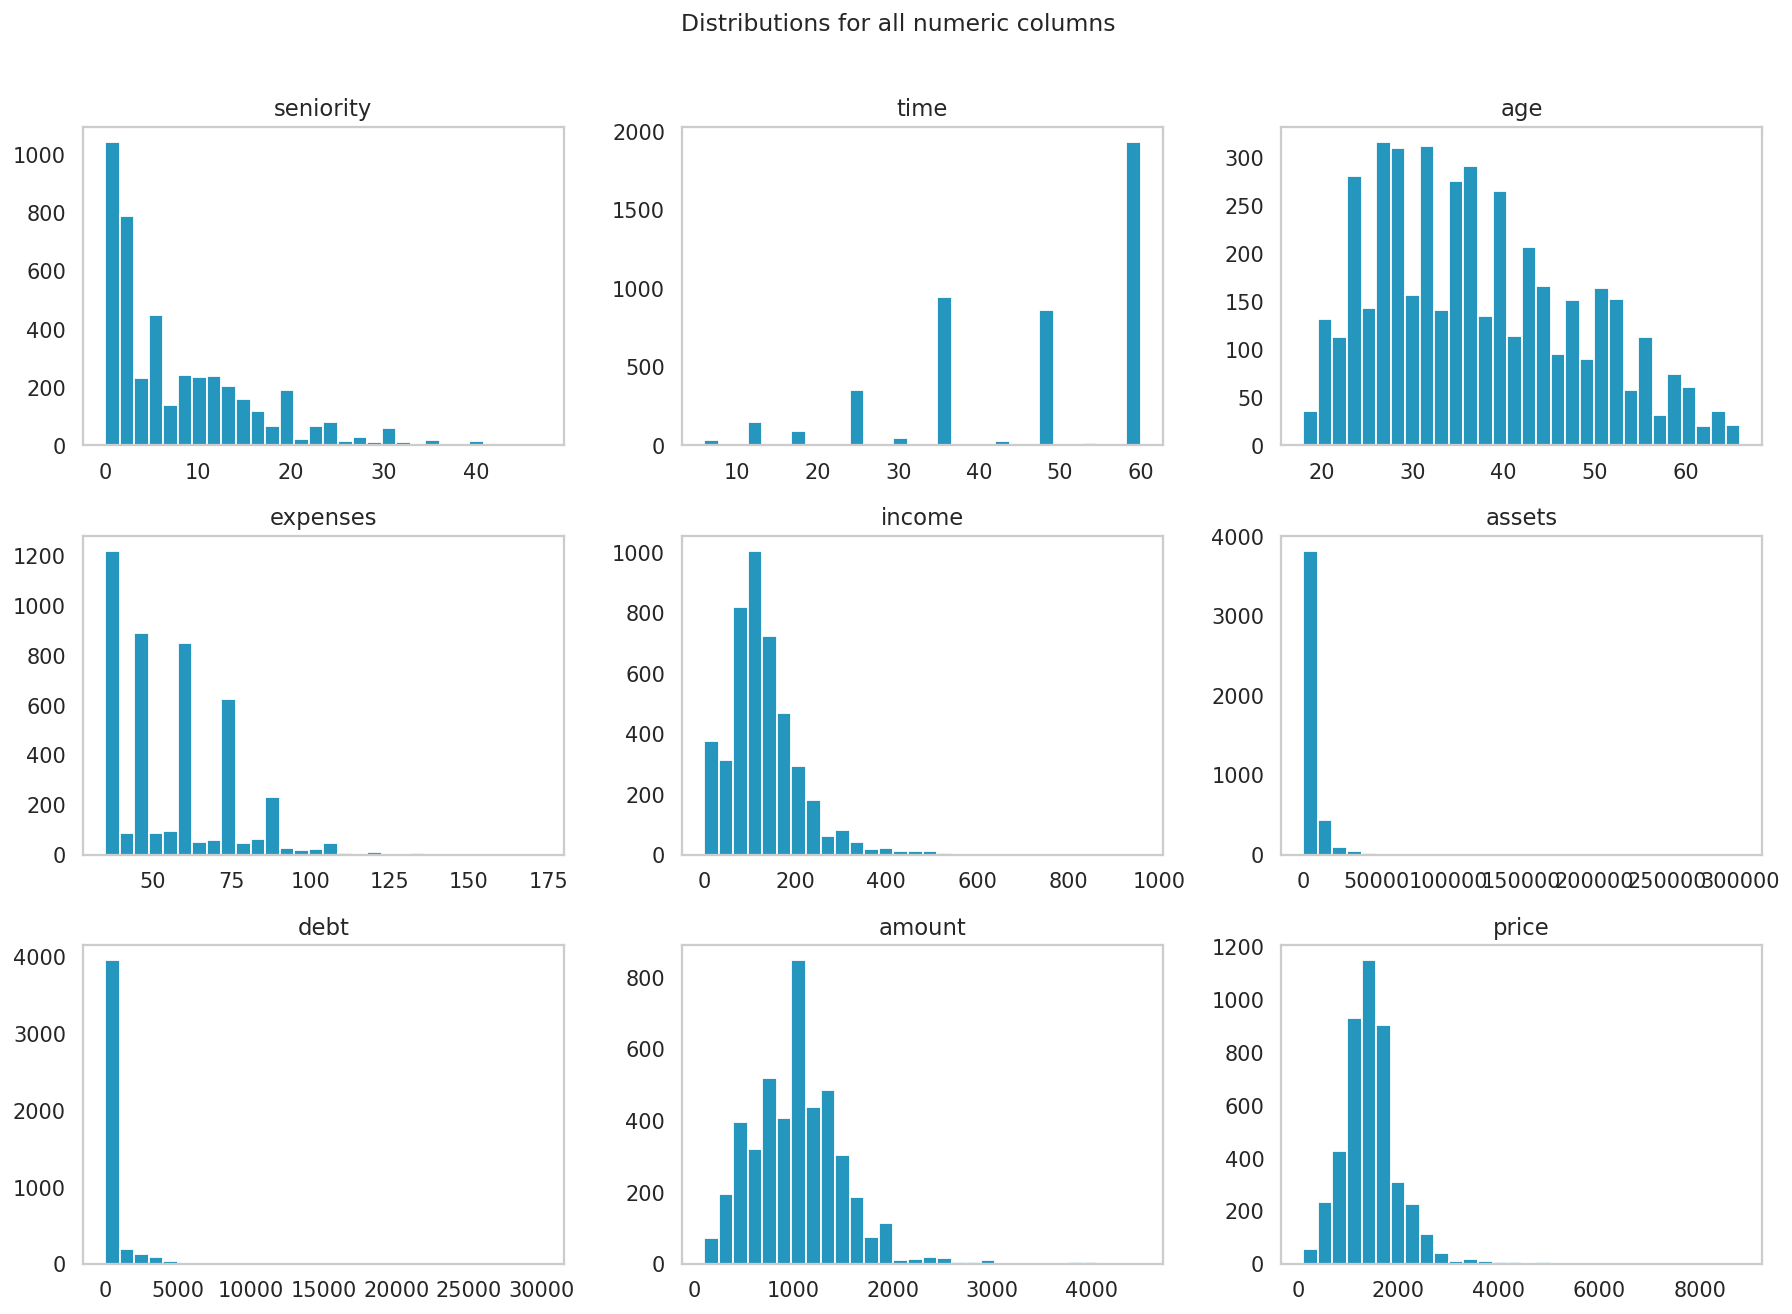

In [84]:
df[num_col].hist(bins=30, figsize=(14, 10), layout=(3, 3), color='#2596be', edgecolor='white', grid=False)
plt.suptitle('Distributions for all numeric columns', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Using groupby to evaluate the defaulting in each group
- typically clients who defaulted had 2 years of seniority, incomparison to a typical client who did not default with about 7 years of experience. suggesting that job stability and carrer establishment may be stronger indicators of repayment ability than income alone.
- A typical client who defaulted had no measurable assets at all, compared to 4000 for those who did not default — suggesting that asset ownership, or the lack of it, may be one of the clearest separators between the two groups in this dataset
- 

In [85]:
df.groupby('status')[num_col].mean()

,seniority,time,age,expenses,income,assets,debt,amount,price
status,,,,,,,,,
0,9.305842,45.52015,37.711653,55.214620,141.724774,6077.319275,333.742580,993.170572,1455.648860
1,4.586922,48.77512,35.408293,56.369617,101.803030,3593.172249,361.525518,1152.873206,1473.555821


In [89]:
from IPython.display import display
for col in num_col:
    print(col)
    df_summary = df.groupby('status')[col].agg(['mean', 'std', 'median', 'count'])
    display(df_summary)

seniority


,mean,std,median,count
status,,,,
0,9.305842,8.459344,7.0,3201
1,4.586922,6.118022,2.0,1254


time


,mean,std,median,count
status,,,,
0,45.52015,15.202703,48.0,3201
1,48.77512,12.847643,48.0,1254


age


...

,mean,std,median,count
status,,,,
0,333.742580,1141.627757,0.0,3201
1,361.525518,1472.341714,0.0,1254


amount


,mean,std,median,count
status,,,,
0,993.170572,440.013372,1000.0,3201
1,1152.873206,524.553870,1100.0,1254


price


,mean,std,median,count
status,,,,
0,1455.648860,575.168122,1400.0,3201
1,1473.555821,694.590653,1423.0,1254


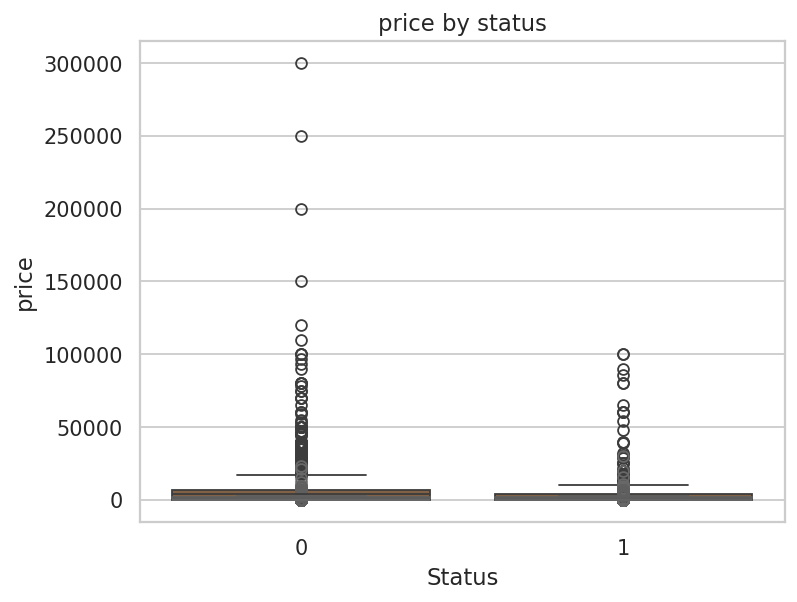

In [116]:
#box plot
for col in num_col:
    sns.boxplot(data=df, x='status', y=col)
    plt.title(f'{col} by status')
    plt.xlabel("Status")
    plt.ylabel(f'{col}')
plt.show()
                


## Crosstab: To compare categorical columns 
### insights
-Job type showed the strongest categorical separation in the dataset. Clients with part-time employment defaulted at a rate of 60%, compared to 33% for freelancers and only 20% for those in fixed employment.suggesting that employment stability, not just income level, is a significant driver of default risk

In [103]:
# pd.crosstab counts how many times each combination of values appears
ct = pd.crosstab(df['job'], df['status'])
ct_pct = pd.crosstab(df['job'], df['status'], normalize='index').round(2) * 100
ct_pct

status,0,1
job,,
fixed,79.0,21.0
freelance,67.0,33.0
others,60.0,40.0
partime,40.0,60.0
unknown,0.0,100.0


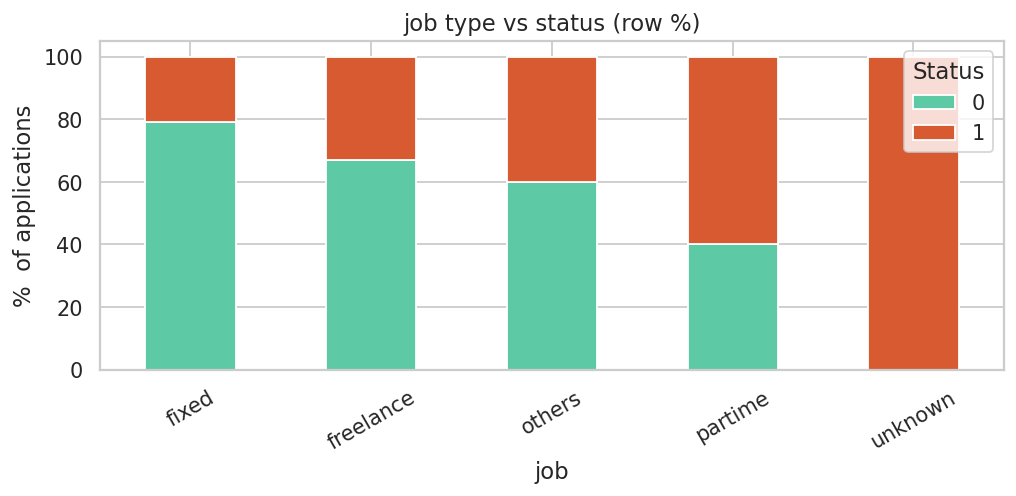

In [117]:
#plotting the cross tab
ct_pct.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#5DCAA5', "#D85A30", "#7F77DD"], edgecolor='white')
plt.title('job type vs status (row %)')
plt.xlabel('job')
plt.ylabel('%  of applications')
plt.xticks(rotation=30)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

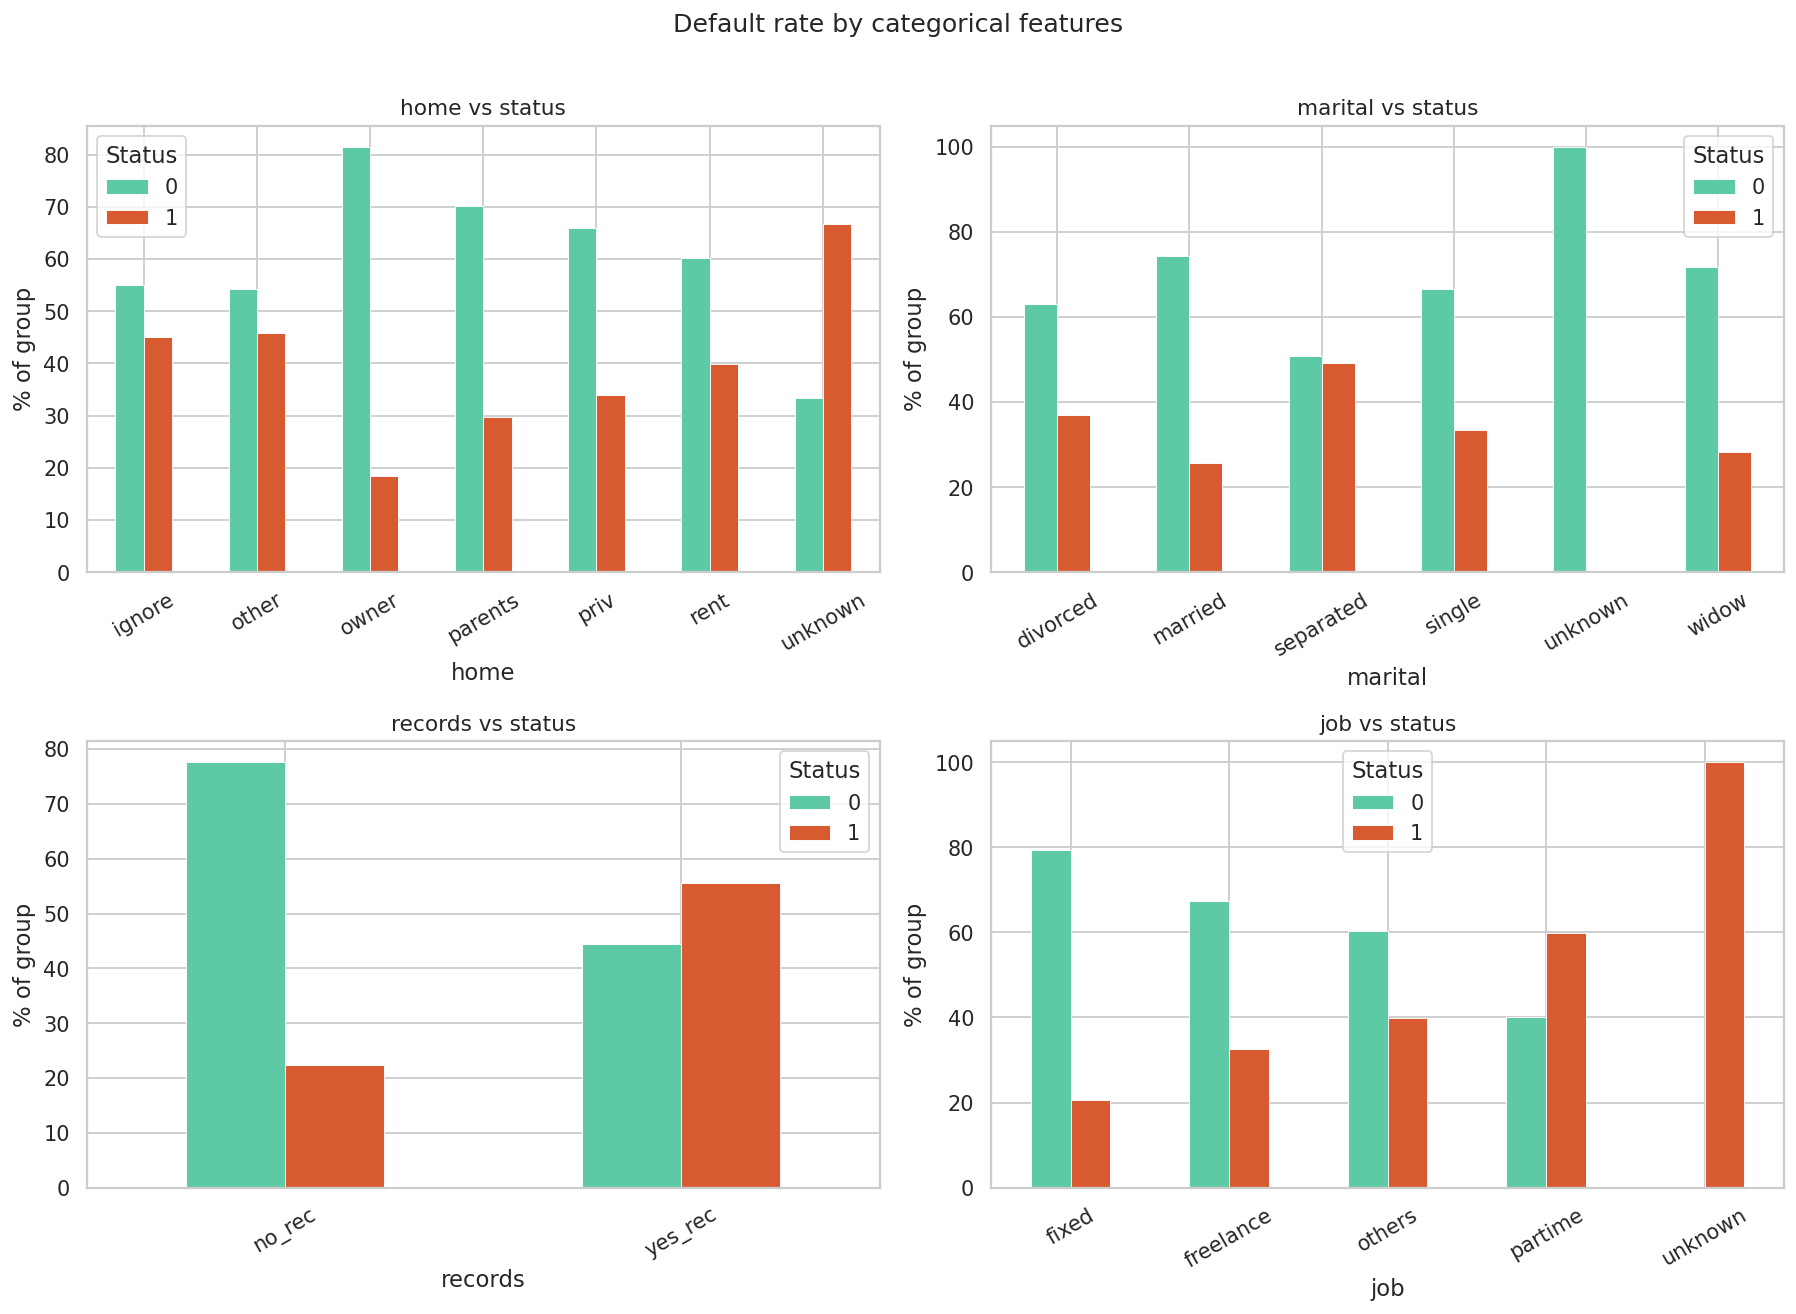

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    ct = pd.crosstab(df[col], df['status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i],
            color=["#5DCAA5", "#D85A30"],
            edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col} vs status', fontsize=12, fontweight='500')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% of group')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Status')

plt.suptitle('Default rate by categorical features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

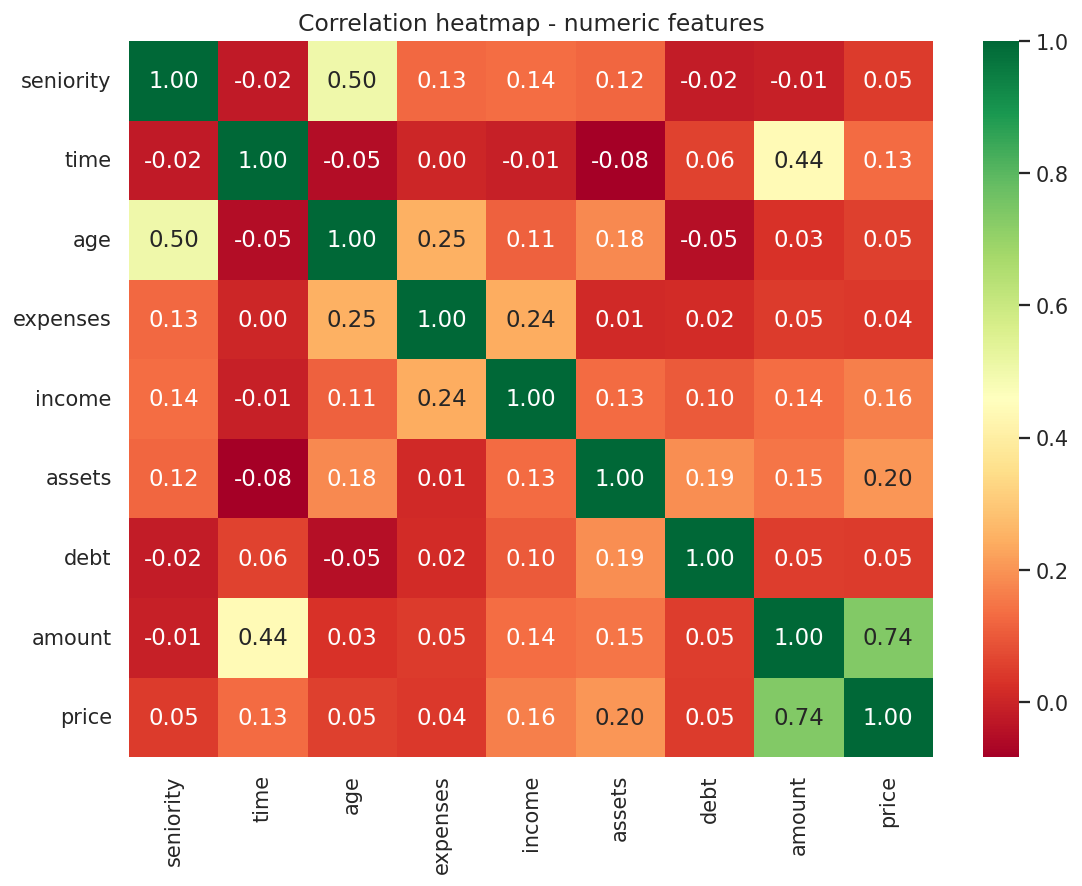

In [105]:
#correlation 
corr = df[num_col].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn' )
plt.title('Correlation heatmap - numeric features', fontsize=13)
plt.tight_layout()
plt.show()

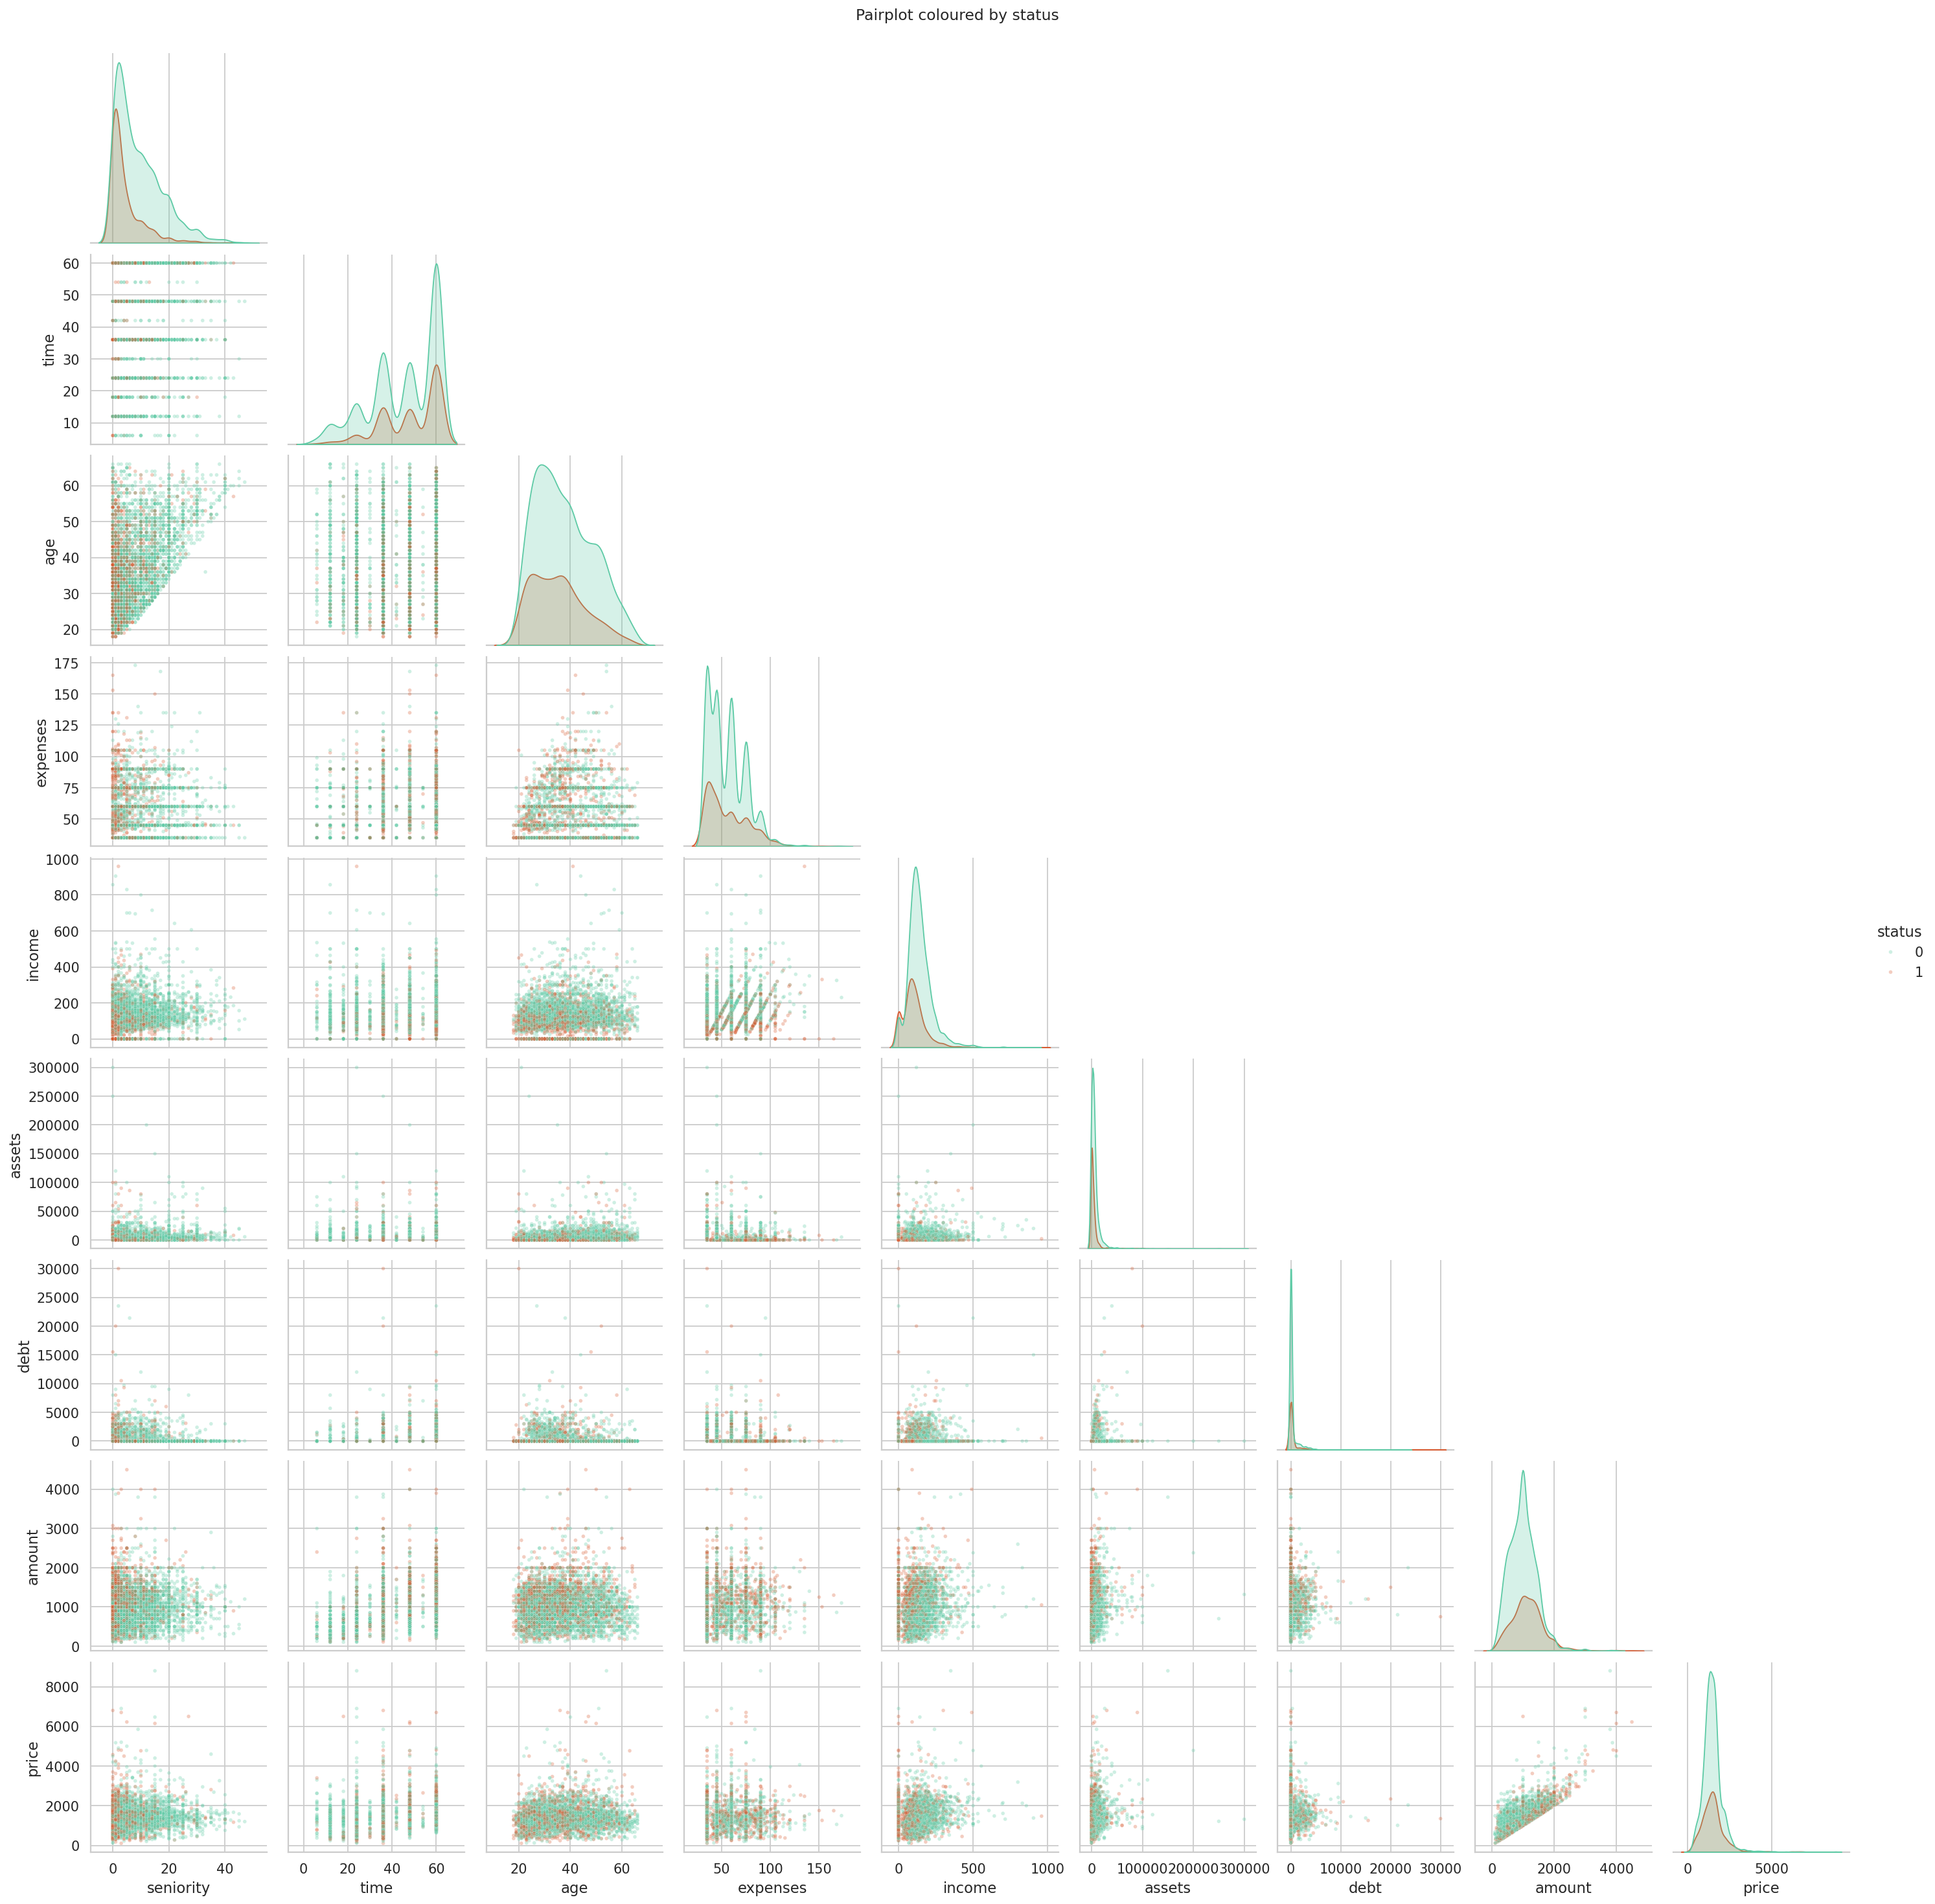

In [112]:
key_cols = ['status', 'seniority',
             'time',
             'age',
             'expenses',
             'income',
             'assets',
             'debt',
             'amount',
             'price']

sns.pairplot(df[key_cols], hue='status', 
             palette=["#5DCAA5", "#D85A30"],
             diag_kind='kde',
             plot_kws={'alpha': 0.3, 's':10},
             corner=True)
plt.suptitle('Pairplot coloured by status', y=1.01, fontsize=13)
plt.show()

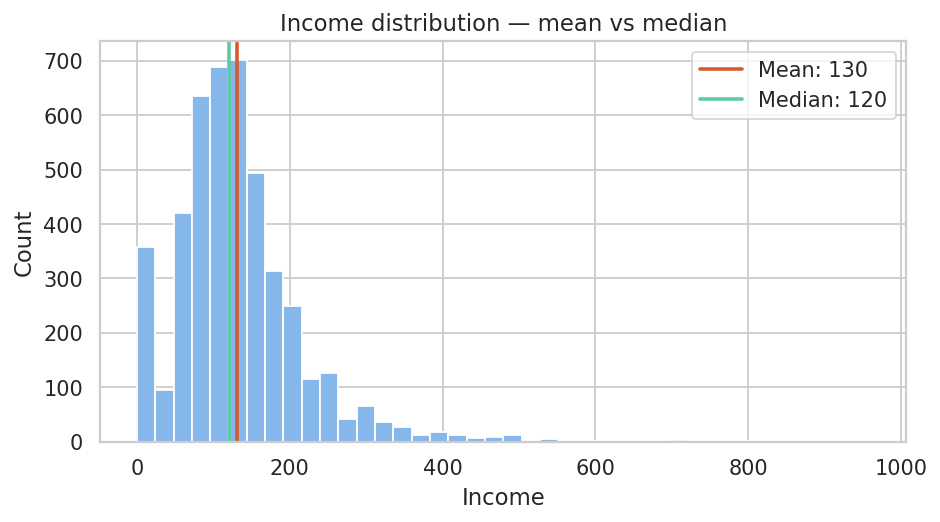

In [120]:
92/127

0.7244094488188977